# Advanced Model Evaluation

#### 1. Import Libraries

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import(
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

#### 2. Load Dataset

In [16]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)
print("Dataset shape:", X.shape)
print("Target classes:", y.unique())

Dataset shape: (569, 30)
Target classes: [0 1]


#### 3. Train–Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


#### 4. Train LogisticRegression Model

In [19]:
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

#### 5. Make Predictions

In [21]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  

#### 6. Confusion Matrix

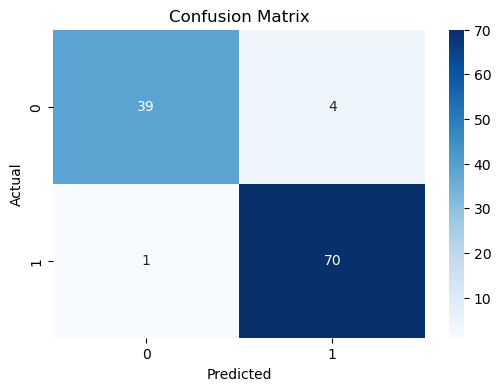

In [27]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize= (6, 4))
sns.heatmap(cm,annot=True, fmt = 'd', cmap = 'Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


#### 7. Evaluation Metrics

In [28]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.956140350877193


In [29]:
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.9459459459459459


In [30]:
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.9859154929577465


In [31]:
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.9655172413793104


#### 8. ROC curve

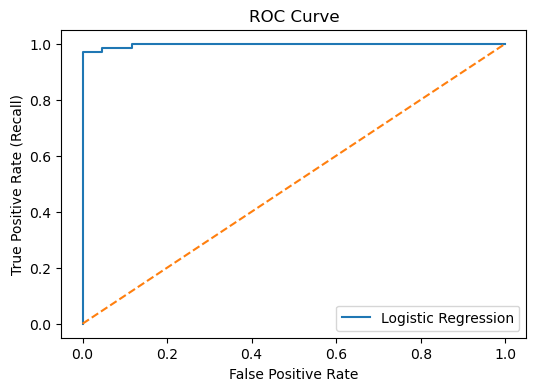

In [32]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()

#### AUC Score

In [33]:
auc = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc)

AUC Score: 0.9977071732721913
